In [4]:
%pip install faiss-cpu pypdf langchain-huggingface

  Using cached faiss_cpu-1.15.0-cp314-cp314-win_amd64.whl.metadata (7.8 kB)
  Using cached langchain_huggingface-1.2.2-py3-none-any.whl.metadata (4.0 kB)
  Using cached huggingface_hub-1.28.0-py3-none-any.whl.metadata (16 kB)
  Using cached tokenizers-0.23.1-cp310-abi3-win_amd64.whl.metadata (10 kB)
  Using cached filelock-3.32.3-py3-none-any.whl.metadata (2.0 kB)
  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
  Using cached hf_xet-1.6.0-cp38-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
Using cached faiss_cpu-1.15.0-cp314-cp314-win_amd64.whl (16.5 MB)
Using cached langchain_huggingface-1.2.2-py3-none-any.whl (31 kB)
Using cached huggingface_hub-1.28.0-py3-none-any.whl (793 kB)
Using cached hf_xet-1.6.0-cp38-abi3-win_amd64.whl (4.0 MB)
Using cached tokenizers-0.23.1-cp310-abi3-win_amd64.whl (2.8 MB)
Using cached filelock-3.32.3-py3-none-any.whl (98 kB)
Using cached fsspec-2026.7.0-py3-none-any.whl (206 kB)
Using cach


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
%pip install langchain_text_splitters langchain_community

  Using cached langchain_community-0.4.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached aiohttp-3.14.3-cp314-cp314-win_amd64.whl.metadata (8.5 kB)
  Using cached httpx_sse-0.4.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached langchain_classic-1.0.8-py3-none-any.whl.metadata (5.1 kB)
  Using cached pydantic_settings-2.15.0-py3-none-any.whl.metadata (3.9 kB)
  Using cached sqlalchemy-2.0.52-cp314-cp314-win_amd64.whl.metadata (9.9 kB)
  Using cached aiohappyeyeballs-2.7.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached frozenlist-1.8.0-cp314-cp314-win_amd64.whl.metadata (21 kB)
  Using cached multidict-6.7.1-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached propcache-0.5.2-cp314-cp314-win_amd64.whl.metadata (17 kB)
  Using cached yarl-1.24.5-cp314-cp314-win_amd64.whl.metadata (107 kB)
  Using cached greenlet-3.5.5-cp314-cp314-win_amd64.whl.metadata (3.9 kB)
Using cached langchain_community-0.4.2-py3-none-an


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:

from langchain_groq import ChatGroq 
from langchain_huggingface import HuggingFaceEmbeddings 
from langchain_text_splitters import RecursiveCharacterTextSplitter
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

C:\Users\aksha\AppData\Local\Temp\ipykernel_24164\3311943934.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [7]:
load_dotenv()

True

In [8]:
llm = ChatGroq(model="qwen/qwen3.6-27b", temperature=0.6)

In [12]:
loader = PyPDFLoader("book.pdf")
docs = loader.load()
len(docs)

51

In [13]:
splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=150)
chunks = splitter.split_documents(docs)
len(chunks)

161

In [18]:
!pip install sentence-transformers

In [21]:
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vector_store = FAISS.from_documents(chunks, embeddings)
vector_store

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2602.21it/s]


In [22]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':3})

In [23]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [24]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [25]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    
def chat_node(state: ChatState):

    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

tool_node = ToolNode(tools)

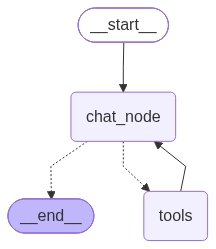

In [26]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()
chatbot

In [27]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain the concept of five"
                )
            )
        ]
    }
)

In [28]:
print(result['messages'][-1].content)

Based on the provided notes from Miyamoto Musashi's *The Book of Five Rings* (Go Rin no Sho), the "concept of five" refers to the division of the treatise into five books, each representing a different element of battle and life.

Here is an explanation of the concept based on the text:

*   **Elemental Philosophy**: The five books are grounded in the idea that there are different physical elements in life, as described in Eastern religions like Buddhism and Shinto. These elements serve as a framework for understanding the different aspects of strategy and combat.
*   **The Elements Mentioned**:
    *   **The Ground Book (Earth)**: This book covers the "shallowest things and the deepest things." It is described as a foundation, "as if it were a straight road mapped out on the ground."
    *   **The Water Book (Water)**: This section focuses on the spirit becoming like water—adaptable, taking the shape of its receptacle, and possessing a "clear blue colour." It emphasizes that mastering